In [6]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [7]:
nav = pd.read_csv(
    "../Data/raw/02_nav_history.csv"
)

performance = pd.read_csv(
    "../Data/raw/07_scheme_performance.csv"
)

benchmark = pd.read_csv(
    "../Data/raw/10_benchmark_indices.csv"
)

In [8]:
print(nav.head())
print("\n")
print(performance.head())

   amfi_code        date      nav
0     119551  2022-01-03  54.3856
1     119551  2022-01-04  54.3474
2     119551  2022-01-05  54.6869
3     119551  2022-01-06  55.4550
4     119551  2022-01-07  55.3692


   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct      

In [9]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


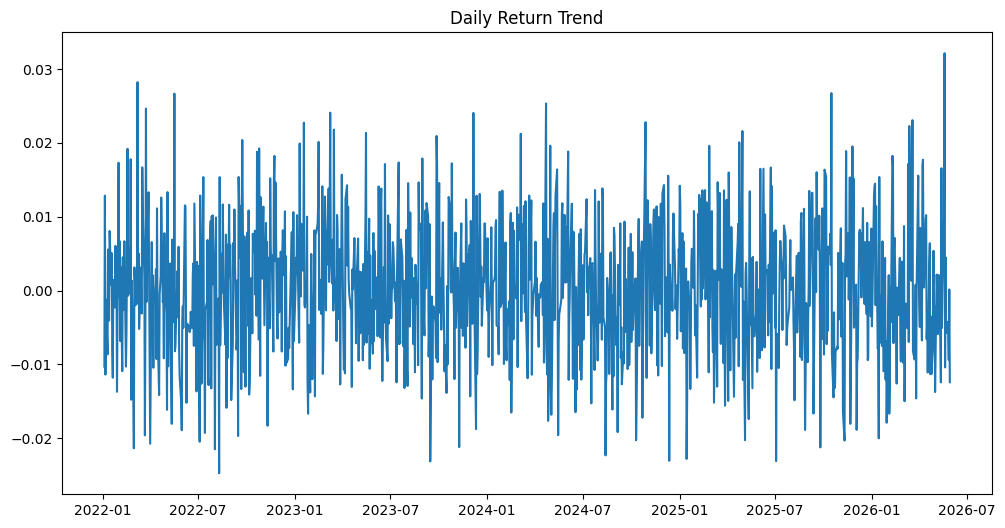

In [10]:
sample_fund = nav[
    nav["amfi_code"] ==
    nav["amfi_code"].iloc[0]
]

plt.figure(figsize=(12,6))

plt.plot(
    sample_fund["date"],
    sample_fund["daily_return"]
)

plt.title("Daily Return Trend")

plt.show()

## Insight 1

Daily returns fluctuate around zero with occasional spikes reflecting market volatility.

In [11]:
top_cagr = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

top_cagr[
    [
        "scheme_name",
        "return_5yr_pct"
    ]
]

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
39,DSP Small Cap Fund - Regular - Growth,20.61
38,DSP Midcap Fund - Regular - Growth,19.00
26,Axis Midcap Fund - Regular - Growth,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69


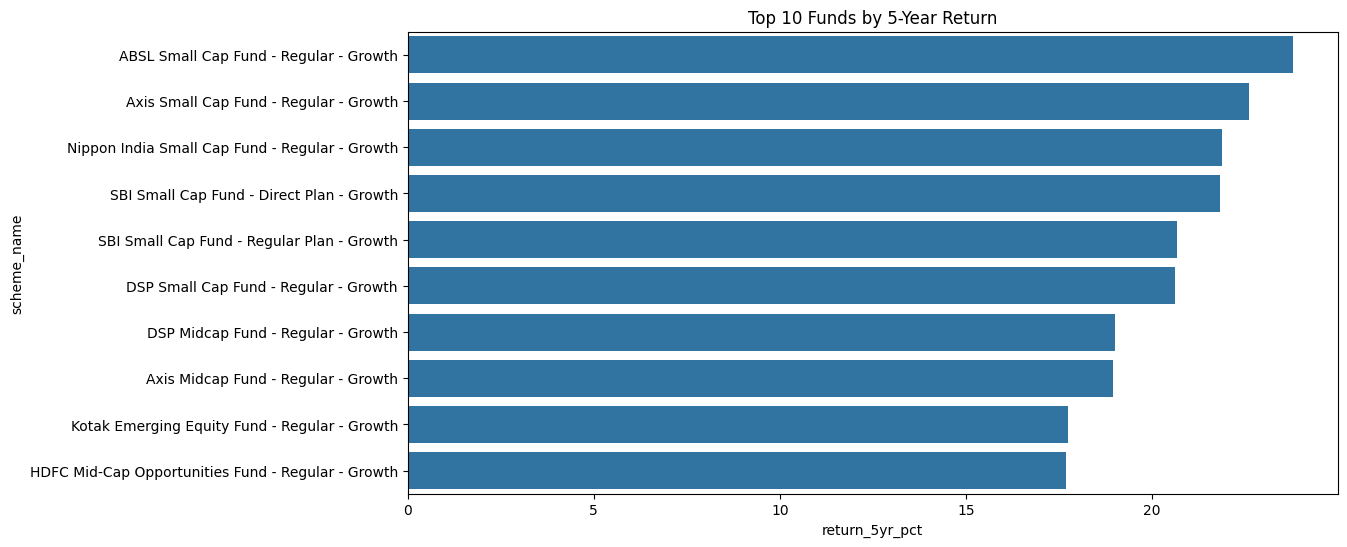

In [12]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_cagr,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title(
    "Top 10 Funds by 5-Year Return"
)

plt.show()

## Insight 2

A small set of funds significantly outperform peers on long-term returns.

In [13]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top_sharpe[
    [
        "scheme_name",
        "sharpe_ratio"
    ]
]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


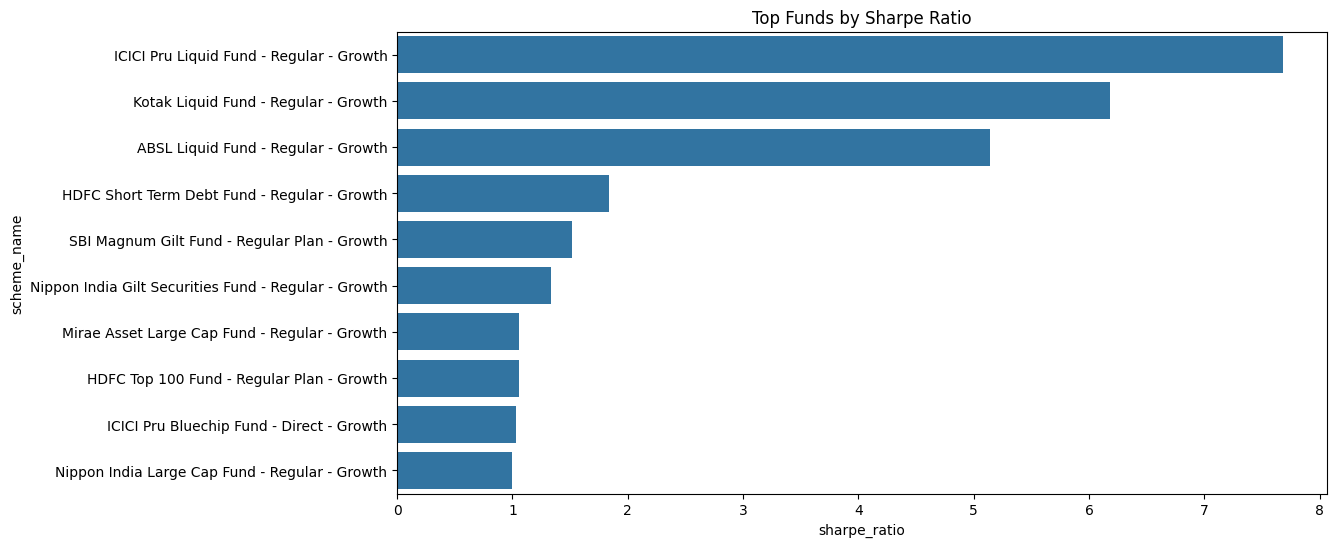

In [14]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title(
    "Top Funds by Sharpe Ratio"
)

plt.show()

## Insight 3

Higher Sharpe ratios indicate superior risk-adjusted performance.

In [15]:
top_sortino = performance.sort_values(
    "sortino_ratio",
    ascending=False
).head(10)

top_sortino[
    [
        "scheme_name",
        "sortino_ratio"
    ]
]

,scheme_name,sortino_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,10.37
23,Kotak Liquid Fund - Regular - Growth,9.70
30,ABSL Liquid Fund - Regular - Growth,8.76
9,HDFC Short Term Debt Fund - Regular - Growth,2.79
19,Nippon India Gilt Securities Fund - Regular - ...,2.38
4,SBI Magnum Gilt Fund - Regular Plan - Growth,2.11
5,HDFC Top 100 Fund - Regular Plan - Growth,1.70
15,Nippon India Large Cap Fund - Regular - Growth,1.68
3,SBI Small Cap Fund - Direct Plan - Growth,1.67
34,Mirae Asset Large Cap Fund - Regular - Growth,1.66


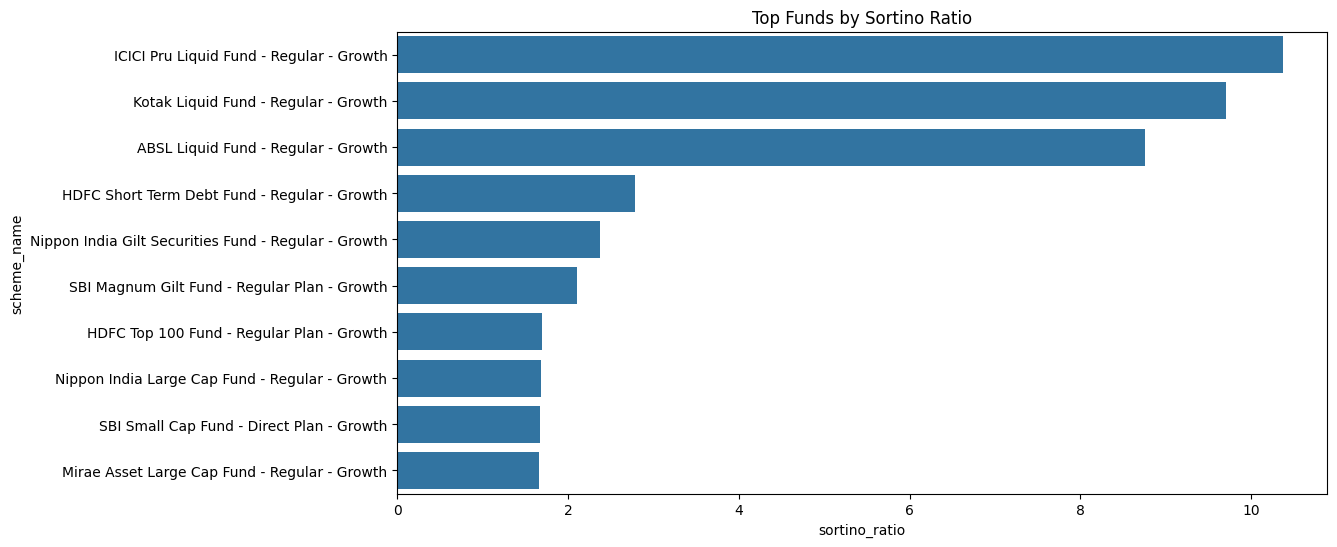

In [16]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top Funds by Sortino Ratio")

plt.show()

## Insight 4

Funds with high Sortino ratios generate strong returns while limiting downside risk.

In [17]:
alpha_beta = performance[
    [
        "scheme_name",
        "alpha",
        "beta"
    ]
]

alpha_beta.head()

,scheme_name,alpha,beta
0,SBI Bluechip Fund - Regular Plan - Growth,0.87,0.89
1,SBI Bluechip Fund - Direct Plan - Growth,1.78,0.87
2,SBI Small Cap Fund - Regular Plan - Growth,1.23,0.89
3,SBI Small Cap Fund - Direct Plan - Growth,1.13,1.04
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.60,0.22


In [18]:
alpha_beta.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

print("alpha_beta.csv saved")

alpha_beta.csv saved


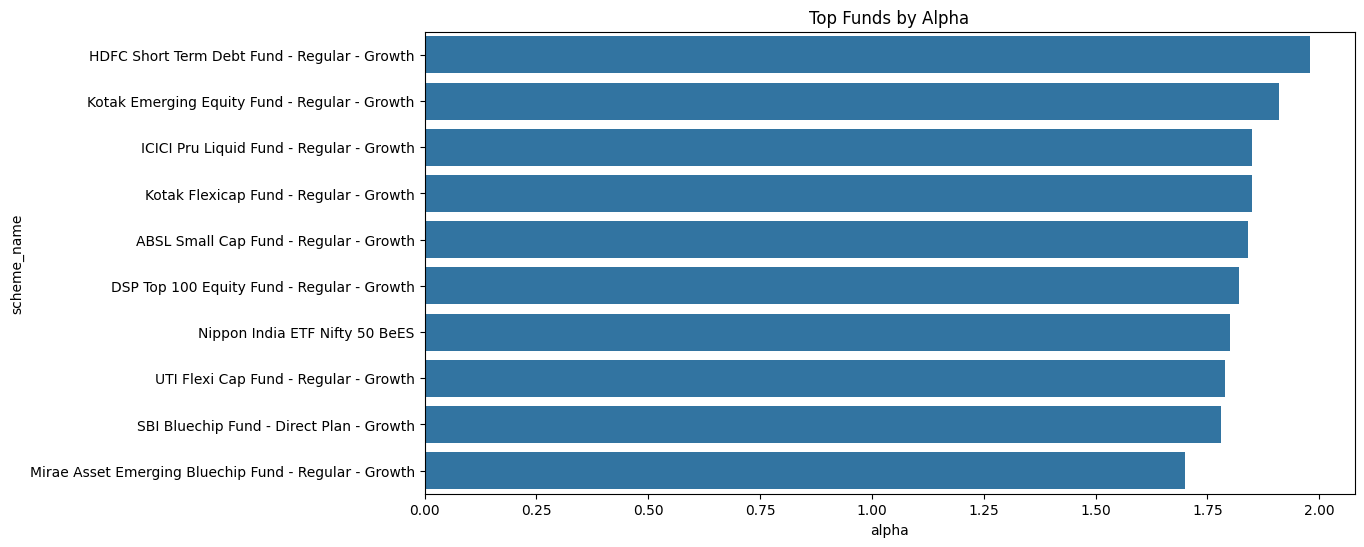

In [19]:
top_alpha = performance.sort_values(
    "alpha",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_alpha,
    x="alpha",
    y="scheme_name"
)

plt.title("Top Funds by Alpha")

plt.show()

## Insight 5

Higher alpha values indicate funds outperforming their benchmark after adjusting for market risk.

In [20]:
drawdown = performance.sort_values(
    "max_drawdown_pct"
).head(10)

drawdown[
    [
        "scheme_name",
        "max_drawdown_pct"
    ]
]

,scheme_name,max_drawdown_pct
6,HDFC Top 100 Fund - Direct Plan - Growth,-33.50
35,Mirae Asset Emerging Bluechip Fund - Regular -...,-33.15
26,Axis Midcap Fund - Regular - Growth,-32.38
8,HDFC Mid-Cap Opportunities Fund - Direct - Growth,-32.22
17,Nippon India Small Cap Fund - Regular - Growth,-30.87
24,Axis Bluechip Fund - Regular - Growth,-27.54
38,DSP Midcap Fund - Regular - Growth,-26.99
18,Nippon India ETF Nifty 50 BeES,-26.75
11,ICICI Pru Bluechip Fund - Direct - Growth,-26.59
10,ICICI Pru Bluechip Fund - Regular - Growth,-25.91


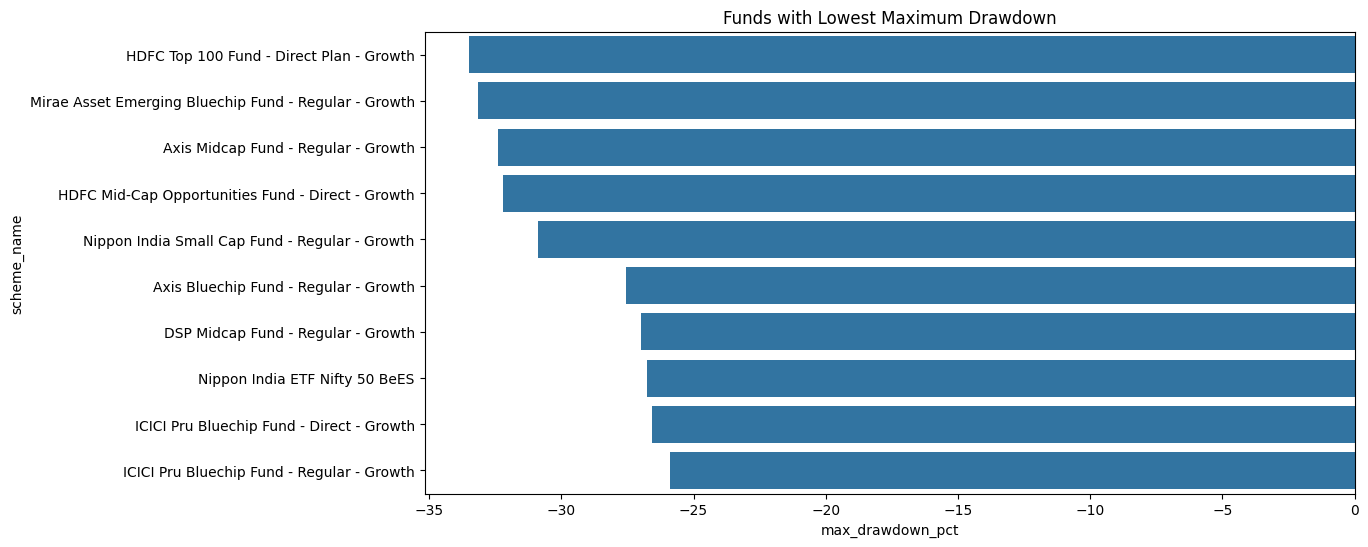

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=drawdown,
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Funds with Lowest Maximum Drawdown")

plt.show()

## Insight 6

Lower drawdowns indicate better capital preservation during market downturns.

In [22]:
performance["fund_score"] = (
    performance["return_3yr_pct"].rank(pct=True) * 30
    +
    performance["sharpe_ratio"].rank(pct=True) * 25
    +
    performance["alpha"].rank(pct=True) * 20
    +
    (1/performance["expense_ratio_pct"]).rank(pct=True) * 15
    +
    (1/abs(performance["max_drawdown_pct"])).rank(pct=True) * 10
)

performance[
    [
        "scheme_name",
        "fund_score"
    ]
].head()

,scheme_name,fund_score
0,SBI Bluechip Fund - Regular Plan - Growth,33.6250
1,SBI Bluechip Fund - Direct Plan - Growth,41.5625
2,SBI Small Cap Fund - Regular Plan - Growth,70.6250
3,SBI Small Cap Fund - Direct Plan - Growth,68.0000
4,SBI Magnum Gilt Fund - Regular Plan - Growth,60.5000


In [23]:
scorecard = performance[
    [
        "scheme_name",
        "fund_score"
    ]
]

scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

print("fund_scorecard.csv saved")

fund_scorecard.csv saved


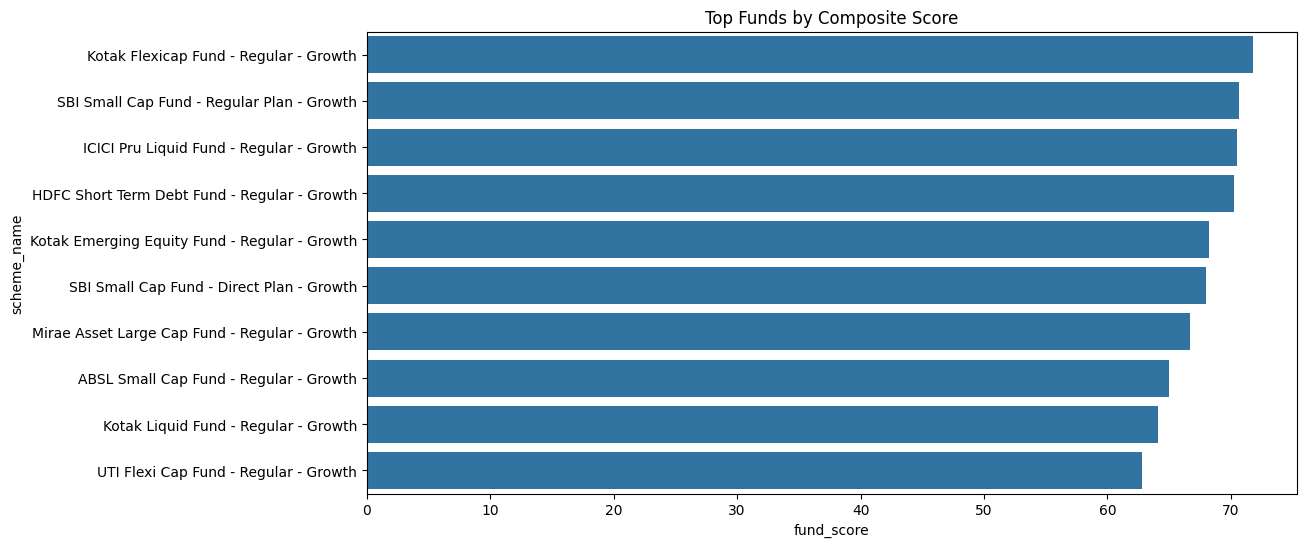

In [24]:
top_score = performance.sort_values(
    "fund_score",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_score,
    x="fund_score",
    y="scheme_name"
)

plt.title("Top Funds by Composite Score")

plt.show()

## Insight 7

The composite score combines returns, risk-adjusted performance, alpha, expenses and drawdown into a single ranking metric.